# Counter-UAS Glider Infiltration — Scratch Notebook

Clean, self-contained implementation. No OOP. Everything in one file.

**Scenario:** Fixed-wing UAS infiltrates a defended corridor.
- Phase 1: Powered climb at fixed climb rate
- Phase 2: Unpowered glide, divided into N segments each with its own gamma
- One sensor suite collocated at z_d
- Attacker minimizes cumulative detection probability J_PD

**Nonholonomic constraint:** v and gamma are coupled through the glide polar.
The attacker cannot choose them independently — once gamma is chosen,
trim airspeed v(gamma) is determined by the parabolic drag polar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize

print('Imports OK')

Imports OK


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


---
## Section 1 — Constants
All tunable parameters in one place. Change these freely.

In [2]:
# ── Corridor ────────────────────────────────────────────────────────────────
Z_START   = 0.0        # m  corridor start
Z_GOAL    = 10000.0    # m  corridor end / target
H_MAX     = 10000.0    # m  max altitude (reference only, not enforced)

# ── Defender sensor placement (heuristic) ───────────────────────────────────
Z_D       = 3000.0     # m  sensor collocated at this position on ground

# ── Airframe (parabolic drag polar) ─────────────────────────────────────────
C_D0      = 0.025      # zero-lift drag coefficient
K_INDUCED = 0.045      # induced drag factor  k = 1/(pi*e*AR)
W         = 150.0      # N  vehicle weight
RHO       = 1.225      # kg/m^3  air density (sea level ISA)
S_WING    = 0.8        # m^2  wing reference area

# ── Powered phase ───────────────────────────────────────────────────────────
V_CLIMB   = 25.0       # m/s  horizontal airspeed during climb (constant)
H_DOT_MAX = 5.0        # m/s  maximum climb rate
H_SW_MIN = 200.0

# ── Glide phase ─────────────────────────────────────────────────────────────
H_SW_TYPICAL = 1000.0
GAMMA_MIN = np.radians(-90.0)   # rad  steepest allowable glide angle
GAMMA_MAX = np.radians(-2.0)    # rad  shallowest allowable glide angle
N_SEG     = 10                  # number of glide segments

# ── Simulation ──────────────────────────────────────────────────────────────
DT        = 0.1        # s  timestep

# ── Sensor kappas ───────────────────────────────────────────────────────────
# These will be calibrated in Section 3.
# Initial values are placeholders.
KAPPA_AC   = 1.0e-4    # acoustic
KAPPA_DOPP = 1.0e-6    # Doppler radar
KAPPA_RCS  = 1.0e-6    # RCS radar
KAPPA_CAM  = 5.0e-5    # camera

# RCS model spread (deg)
SIGMA_PSI_DEG = 30.0

# Camera FOV half-angle (deg) and elevation (deg)
FOV_HALF_DEG      = 45.0
CAM_ELEVATION_DEG = 45.0

# Acoustic velocity exponent
N_ACOUSTIC = 6.0

print('Constants set.')
print(f'  Corridor:  z=[{Z_START:.0f}, {Z_GOAL:.0f}] m')
print(f'  Sensor:    z_d={Z_D:.0f} m')
print(f'  Segments:  N={N_SEG}')

Constants set.
  Corridor:  z=[0, 10000] m
  Sensor:    z_d=3000 m
  Segments:  N=10


---
## Section 2 — Glide Polar

Parabolic drag polar: C_D = C_D0 + k*C_L^2

At best glide (C_L = C_L*), induced drag equals parasitic drag.
The nonholonomic constraint: once gamma is chosen, trim airspeed v(gamma)
is determined. Attacker cannot choose v and gamma independently.

In [3]:
# ── Precompute best-glide quantities from polar ──────────────────────────────

CL_STAR    = np.sqrt(C_D0 / K_INDUCED)           # lift coeff at best glide
CD_STAR    = C_D0 + K_INDUCED * CL_STAR**2       # = 2*C_D0 at best glide
LD_MAX     = CL_STAR / CD_STAR                    # max lift-to-drag ratio
GAMMA_STAR = -np.arctan(1.0 / LD_MAX)             # best glide angle (negative)
V_STAR     = np.sqrt(2*W*np.cos(abs(GAMMA_STAR)) / (RHO*S_WING*CL_STAR))

print(f'Glide polar:')
print(f'  CL*        = {CL_STAR:.4f}')
print(f'  CD*        = {CD_STAR:.4f}  (= 2*C_D0 = {2*C_D0:.4f} ✓)')
print(f'  (L/D)_max  = {LD_MAX:.2f}')
print(f'  gamma*     = {np.degrees(GAMMA_STAR):.2f} deg  (best glide angle)')
print(f'  v*         = {V_STAR:.2f} m/s  (best glide speed)')


def cl_from_gamma(gamma):
    """
    Invert the force balance to find C_L given gamma.
    From: tan|gamma| = (C_D0 + k*C_L^2) / C_L
    => k*C_L^2 - tan|gamma|*C_L + C_D0 = 0
    Take the lower root (stable, high-speed branch).
    """
    gamma = np.clip(gamma, GAMMA_MIN, GAMMA_MAX)
    tan_g = np.tan(abs(gamma))
    disc  = tan_g**2 - 4.0 * K_INDUCED * C_D0
    if disc < 0:
        # gamma shallower than gamma* — physically impossible unpowered
        return CL_STAR
    CL = (tan_g - np.sqrt(disc)) / (2.0 * K_INDUCED)
    return max(CL, 0.01)


def glide_speed(gamma):
    """
    Trim airspeed at glide angle gamma.
    V(gamma) = sqrt(2W cos|gamma| / (rho S CL(gamma)))
    On stable branch: steeper gamma -> lower CL -> higher V.
    """
    gamma = np.clip(gamma, GAMMA_MIN, GAMMA_MAX)
    CL    = cl_from_gamma(gamma)
    return np.sqrt(2*W*np.cos(abs(gamma)) / (RHO*S_WING*CL))


# Quick sanity check: glide_speed at gamma* should return v*
v_check = glide_speed(GAMMA_STAR)
print(f'\nSanity: glide_speed(gamma*) = {v_check:.2f} m/s  (should be {V_STAR:.2f}) ✓')

# Show polar relationship: steeper = faster on stable branch
gammas_test = np.linspace(GAMMA_MIN, GAMMA_MAX, 5)
print(f'\nPolar samples (stable branch):')
print(f'  {"gamma (deg)":>12}  {"v (m/s)":>10}')
for g in gammas_test:
    print(f'  {np.degrees(g):>12.1f}  {glide_speed(g):>10.2f}')

Glide polar:
  CL*        = 0.7454
  CD*        = 0.0500  (= 2*C_D0 = 0.0500 ✓)
  (L/D)_max  = 14.91
  gamma*     = -3.84 deg  (best glide angle)
  v*         = 20.24 m/s  (best glide speed)

Sanity: glide_speed(gamma*) = 20.24 m/s  (should be 20.24) ✓

Polar samples (stable branch):
   gamma (deg)     v (m/s)
         -90.0        0.00
         -68.0      106.54
         -46.0       93.80
         -24.0       70.37
          -2.0       20.26


---
## Section 3 — Sensor Models

Four sensors collocated at (Z_D, 0).
Each returns instantaneous hazard rate lambda_k(z, h, v, gamma, phase) in 1/s.

Detection probability via Poisson fusion (Zabarankin et al. 2006):
    J_PD = 1 - exp(-integral(sum_k lambda_k dt))

In [4]:
# ── Geometry helpers ─────────────────────────────────────────────────────────

# Camera boresight unit vector: points toward z_start at CAM_ELEVATION_DEG
_cam_elev_rad = np.radians(CAM_ELEVATION_DEG)
B_HAT = np.array([-np.cos(_cam_elev_rad), np.sin(_cam_elev_rad)])


def sensor_range(z, h, z_d=Z_D):
    """Euclidean distance from attacker (z,h) to sensor at (z_d, 0)."""
    return np.sqrt((z_d - z)**2 + h**2)


def los_angle(z, h, z_d=Z_D):
    """LOS elevation angle from attacker to sensor (radians, positive)."""
    dz = abs(z_d - z)
    if dz < 1e-6:
        return np.pi / 2.0
    return np.arctan2(h, dz)


def radial_velocity(z, h, v, gamma, z_d=Z_D):
    """
    Velocity component directed toward the sensor.
    v_r = v * cos(theta_los - |gamma|)
    """
    theta = los_angle(z, h, z_d)
    return v * np.cos(theta - abs(gamma))


def aspect_angle_deg(z, h, gamma, z_d=Z_D):
    """
    Angle between aircraft ventral normal and radar LOS (degrees).
    Worst case (max RCS) at psi=90 deg (belly facing radar).
    """
    theta        = los_angle(z, h, z_d)
    ventral_ang  = np.pi / 2.0 + gamma   # gamma negative for descent
    psi          = abs(ventral_ang - theta)
    return np.degrees(psi)


def boresight_angle(z, h, z_d=Z_D):
    """Angle between camera boresight and direction to attacker (radians)."""
    u      = np.array([z - z_d, h])
    u_norm = np.linalg.norm(u)
    if u_norm < 1e-6:
        return 0.0
    u_hat = u / u_norm
    dot   = np.clip(np.dot(B_HAT, u_hat), -1.0, 1.0)
    return np.arccos(dot)


# ── Sensor hazard rate functions ──────────────────────────────────────────────

def lambda_acoustic(z, h, v, gamma, phase, z_d=Z_D,
                    kappa=None, n=N_ACOUSTIC):
    """
    Acoustic hazard rate. Active in powered phase only (engine off = silent).
    lambda_ac = kappa * v^n / r^2
    v^n: propeller dipole source strength (Lighthill 1952, Curle 1955)
    r^2: spherical spreading (Pierce 1989)
    """
    if kappa is None: kappa = KAPPA_AC
    if phase != 1:
        return 0.0
    r = sensor_range(z, h, z_d)
    if r < 1.0:
        return 0.0
    return kappa * (v ** n) / (r ** 2)


def lambda_doppler(z, h, v, gamma, phase, z_d=Z_D, kappa=None):
    """
    Doppler radar hazard rate. Active both phases.
    lambda_dopp = kappa * v_r^2 / r^4
    v_r^2: Doppler SNR proportional to f_D^2 = (2v_r/lambda)^2
    r^4: two-way radar range equation (Skolnik 2008)
    """
    if kappa is None: kappa = KAPPA_DOPP
    r   = sensor_range(z, h, z_d)
    if r < 1.0:
        return 0.0
    v_r = radial_velocity(z, h, v, gamma, z_d)
    return kappa * (v_r ** 2) / (r ** 4)


def rcs_model(psi_deg):
    """
    Gaussian RCS model centered at psi=90 deg (belly aspect = worst case).
    sigma(psi) = exp(-(psi - 90)^2 / (2*sigma_psi^2))
    Source: Inanc et al. (2008) JGCD
    """
    sigma_rad = np.radians(SIGMA_PSI_DEG)
    psi_rad   = np.radians(psi_deg)
    return np.exp(-((psi_rad - np.pi/2)**2) / (2 * sigma_rad**2))


def lambda_rcs(z, h, v, gamma, phase, z_d=Z_D, kappa=None):
    """
    RCS radar hazard rate. Active both phases.
    lambda_rcs = kappa * sigma(psi(z,h,gamma)) / r^4
    """
    if kappa is None: kappa = KAPPA_RCS
    r       = sensor_range(z, h, z_d)
    if r < 1.0:
        return 0.0
    psi_deg = aspect_angle_deg(z, h, gamma, z_d)
    sigma   = rcs_model(psi_deg)
    return kappa * sigma / (r ** 4)


def lambda_camera(z, h, v, gamma, phase, z_d=Z_D, kappa=None):
    """
    Camera hazard rate. Active both phases.
    lambda_cam = kappa * cos^2(phi) / r^2   if phi <= FOV_HALF
               = 0                          otherwise
    phi: boresight angle
    r^2: one-way optical propagation
    """
    if kappa is None: kappa = KAPPA_CAM
    r   = sensor_range(z, h, z_d)
    if r < 1.0:
        return 0.0
    phi     = boresight_angle(z, h, z_d)
    fov_rad = np.radians(FOV_HALF_DEG)
    if phi > fov_rad:
        return 0.0
    return kappa * (np.cos(phi) ** 2) / (r ** 2)


def lambda_total(z, h, v, gamma, phase, z_d=Z_D,
                 kappa_ac=None, kappa_dopp=None,
                 kappa_rcs=None, kappa_cam=None):
    """Sum of all four sensor hazard rates."""
    return (lambda_acoustic(z, h, v, gamma, phase, z_d, kappa_ac) +
            lambda_doppler( z, h, v, gamma, phase, z_d, kappa_dopp) +
            lambda_rcs(     z, h, v, gamma, phase, z_d, kappa_rcs) +
            lambda_camera(  z, h, v, gamma, phase, z_d, kappa_cam))


print('Sensor functions defined.')
# Quick check at reference point
z_r, h_r, v_r_check, g_r = 4000.0, 500.0, 22.0, -0.15
print(f'\nSample rates at (z={z_r}, h={h_r}, v={v_r_check}, gamma={np.degrees(g_r):.1f} deg):')
print(f'  acoustic (phase=1): {lambda_acoustic(z_r,h_r,v_r_check,g_r,1):.4e}')
print(f'  doppler  (phase=2): {lambda_doppler( z_r,h_r,v_r_check,g_r,2):.4e}')
print(f'  rcs      (phase=2): {lambda_rcs(     z_r,h_r,v_r_check,g_r,2):.4e}')
print(f'  camera   (phase=2): {lambda_camera(  z_r,h_r,v_r_check,g_r,2):.4e}')

Sensor functions defined.

Sample rates at (z=4000.0, h=500.0, v=22.0, gamma=-8.6 deg):
  acoustic (phase=1): 9.0704e-03
  doppler  (phase=2): 2.8027e-16
  rcs      (phase=2): 3.2205e-19
  camera   (phase=2): 0.0000e+00


---
## Section 4 — Sensor Calibration

Scale kappas so each sensor contributes a hazard integral of ~0.4
over a reference trajectory. Total integral ~1.6 gives J_PD ~0.80.
This ensures the game is non-trivial — attacker can improve by
choosing a better trajectory.

In [5]:
# ── Reference trajectory for calibration ─────────────────────────────────────
# Use a straight-line glide at gamma* (best glide) with moderate h_sw.
# Sensor at midpoint Z_D = 5000 m.

TARGET_INTEGRAL_PER_SENSOR = 0.15   # each sensor contributes 0.4
                                    # total ~1.6 -> J_PD ~0.80

# Calibration trajectory parameters
h_dot_cal = 3.0    # m/s climb rate
gamma_cal = GAMMA_STAR   # best glide

# Minimum feasible h_sw for these parameters
# From: z_sw + h_sw*LD_MAX >= Z_GOAL
#       (Z_START + V_CLIMB*(h_sw/h_dot)) + h_sw*LD_MAX >= Z_GOAL
#       h_sw*(LD_MAX + V_CLIMB/h_dot) >= Z_GOAL - Z_START
h_sw_min_cal = (Z_GOAL - Z_START) / (LD_MAX + V_CLIMB / h_dot_cal)
h_sw_cal     = h_sw_min_cal * 1.5   # 50% above minimum

print(f'Calibration trajectory:')
print(f'  h_dot  = {h_dot_cal} m/s')
print(f'  h_sw   = {h_sw_cal:.1f} m')
print(f'  gamma  = {np.degrees(gamma_cal):.2f} deg  (best glide)')


# ── Simulate reference trajectory ─────────────────────────────────────────────

def simulate_trajectory(h_dot, h_sw, gammas_seg, dt=DT,
                        z_start=Z_START, z_goal=Z_GOAL,
                        v_climb=V_CLIMB):
    """
    Simulate full hybrid trajectory.

    Parameters
    ----------
    h_dot     : float  climb rate (m/s)
    h_sw      : float  engine cutoff altitude (m)
    gammas_seg: array of N_SEG glide angles (rad), one per altitude segment
    
    Returns
    -------
    traj : dict with arrays t, z, h, v, gamma, phase
    """
    # ── Phase 1: powered climb ────────────────────────────────────────────
    h_dot    = np.clip(h_dot, 0.1, H_DOT_MAX)
    t_climb  = h_sw / h_dot
    z_sw     = z_start + v_climb * t_climb

    # In simulate_trajectory, enforce that the trajectory reaches h=0 at z_goal
    # by requiring: z_sw + h_sw * LD_MAX >= Z_GOAL  (already done via delta)
    # AND: the chosen gamma is steep enough to descend h_sw over (Z_GOAL - z_sw)
    # Required gamma: tan|gamma_req| = h_sw / (Z_GOAL - z_sw)
    gamma_req = -np.arctan(h_sw / (z_goal - z_sw))
    # Clip all gammas to be at least as steep as gamma_req
    gammas_seg = np.clip(gammas_seg, GAMMA_MIN, min(GAMMA_MAX, gamma_req))

    # Compute range budget Delta
    delta = z_sw + h_sw * LD_MAX - z_goal
    # if delta < 0:
    #     # Auto-correct h_sw to minimum feasible (silent, no crash)
    #     denom   = LD_MAX + v_climb / h_dot
    #     h_sw    = (z_goal - z_start) / denom * 1.05
    #     t_climb = h_sw / h_dot
    #     z_sw    = z_start + v_climb * t_climb
    #     delta   = z_sw + h_sw * LD_MAX - z_goal

    gamma_climb = np.arctan2(h_dot, v_climb)

    t_list, z_list, h_list, v_list, g_list, phase_list = [], [], [], [], [], []

    t, z, h = 0.0, z_start, 0.0
    while h < h_sw - 1e-3 and z < z_goal:
        t_list.append(t); z_list.append(z); h_list.append(h)
        v_list.append(v_climb); g_list.append(gamma_climb); phase_list.append(1)
        z += v_climb * dt
        h += h_dot   * dt
        t += dt

    # Exact switch point
    t_list.append(t_climb); z_list.append(z_sw); h_list.append(h_sw)
    v_list.append(v_climb); g_list.append(gamma_climb); phase_list.append(1)

    # ── Phase 2: segmented glide ──────────────────────────────────────────
    # Divide h_sw into N_SEG equal altitude bands.
    # Band i covers altitudes [h_sw*(N-i-1)/N, h_sw*(N-i)/N].
    # Each band has its own gamma_i from gammas_seg.
    N       = len(gammas_seg)
    bounds  = np.linspace(h_sw, 0.0, N + 1)   # boundaries[0]=h_sw, [-1]=0

    t   = t_climb
    z   = z_sw
    h   = h_sw
    delta_rem = delta

    # while h > 0.0 and z < z_goal:
    while z < z_goal:
        # Determine which segment we are in
        seg_idx = N - 1   # default: last segment
        for i in range(N):
            if h >= bounds[i + 1]:
                seg_idx = i
                break

        # gamma = np.clip(gammas_seg[seg_idx], GAMMA_MIN, GAMMA_MAX)
        # Dynamic gamma ceiling: must be steep enough to reach ground at z_goal
        z_rem = z_goal - z
        if z_rem > 1.0 and h > 0.1:
            gamma_req_now = -np.arctan(h / z_rem)
            gamma_ceiling = min(GAMMA_MAX, gamma_req_now)
        else:
            gamma_ceiling = GAMMA_MIN   # force steep if nearly out of corridor

        gamma = np.clip(gammas_seg[seg_idx], GAMMA_MIN, gamma_ceiling)

        # Budget enforcement: force gamma* if budget exhausted
        if delta_rem <= 0.0:
            delta_rem = 0.0
            gamma     = GAMMA_STAR

        # Nonholonomic constraint: v determined by gamma through polar
        v     = glide_speed(gamma)
        z_dot = v * np.cos(abs(gamma))
        h_dot_g = v * np.sin(gamma)   # negative (descending)

        t_list.append(t); z_list.append(z); h_list.append(h)
        v_list.append(v); g_list.append(gamma); phase_list.append(2)

        # Decrement range budget
        cot_star  = LD_MAX
        cot_gamma = 1.0 / np.tan(abs(gamma)) if abs(gamma) > 1e-6 else 1e6
        decrement = (cot_star - cot_gamma) * abs(h_dot_g) * dt
        delta_rem -= decrement

        z += z_dot  * dt
        h += h_dot_g * dt
        h = max(h, 0)
        t += dt

    # Final point
    # t_list.append(t); z_list.append(min(z, z_goal)); h_list.append(max(h, 0.0))
    # v_list.append(v); g_list.append(gamma); phase_list.append(2)

    # Replace the final point append
    t_list.append(t)
    z_list.append(min(z, z_goal))
    h_list.append(max(h, 0.0))    # ← clamp to ground, never negative
    v_list.append(v)
    g_list.append(gamma)
    phase_list.append(2)

    return {
        't':     np.array(t_list),
        'z':     np.array(z_list),
        'h':     np.array(h_list),
        'v':     np.array(v_list),
        'gamma': np.array(g_list),
        'phase': np.array(phase_list),
        'h_sw':  h_sw,
        'z_sw':  z_sw,
        'delta': delta,
    }


# Simulate calibration trajectory with N_SEG copies of gamma_cal
gammas_cal = np.full(N_SEG, gamma_cal)
traj_cal   = simulate_trajectory(h_dot_cal, h_sw_cal, gammas_cal)

print(f'\nCalibration trajectory simulated: {len(traj_cal["t"])} points')
print(f'  z_sw = {traj_cal["z_sw"]:.1f} m')
print(f'  h_sw = {traj_cal["h_sw"]:.1f} m')
print(f'  T    = {traj_cal["t"][-1]:.1f} s')


# ── Compute raw integrals with kappa=1 ───────────────────────────────────────

def integrate_sensor_raw(traj, sensor_fn, z_d=Z_D, kappa=1.0):
    """
    Integrate one sensor's hazard rate over a trajectory.
    Uses trapezoidal rule.
    """
    rates = np.array([
        sensor_fn(traj['z'][i], traj['h'][i], traj['v'][i],
                  traj['gamma'][i], traj['phase'][i], z_d, kappa)
        for i in range(len(traj['t']))
    ])
    dt_arr = np.diff(traj['t'])
    return np.sum(0.5 * (rates[:-1] + rates[1:]) * dt_arr)


I_ac_raw   = integrate_sensor_raw(traj_cal, lambda_acoustic, kappa=1.0)
I_dopp_raw = integrate_sensor_raw(traj_cal, lambda_doppler,  kappa=1.0)
I_rcs_raw  = integrate_sensor_raw(traj_cal, lambda_rcs,      kappa=1.0)
I_cam_raw  = integrate_sensor_raw(traj_cal, lambda_camera,   kappa=1.0)

print(f'\nRaw integrals (kappa=1.0):')
print(f'  acoustic : {I_ac_raw:.4e}')
print(f'  doppler  : {I_dopp_raw:.4e}')
print(f'  rcs      : {I_rcs_raw:.4e}')
print(f'  camera   : {I_cam_raw:.4e}')

# Scale kappas so each sensor integral = TARGET
KAPPA_AC   = TARGET_INTEGRAL_PER_SENSOR / I_ac_raw   if I_ac_raw   > 0 else KAPPA_AC
KAPPA_DOPP = TARGET_INTEGRAL_PER_SENSOR / I_dopp_raw if I_dopp_raw > 0 else KAPPA_DOPP
KAPPA_RCS  = TARGET_INTEGRAL_PER_SENSOR / I_rcs_raw  if I_rcs_raw  > 0 else KAPPA_RCS
KAPPA_CAM  = TARGET_INTEGRAL_PER_SENSOR / I_cam_raw  if I_cam_raw  > 0 else KAPPA_CAM

print(f'\nCalibrated kappas:')
print(f'  KAPPA_AC   = {KAPPA_AC:.4e}')
print(f'  KAPPA_DOPP = {KAPPA_DOPP:.4e}')
print(f'  KAPPA_RCS  = {KAPPA_RCS:.4e}')
print(f'  KAPPA_CAM  = {KAPPA_CAM:.4e}')

# Verify total J_PD on calibration trajectory
I_total_cal = (TARGET_INTEGRAL_PER_SENSOR * 4)   # by construction
J_PD_cal    = 1.0 - np.exp(-I_total_cal)
print(f'\nVerification on calibration trajectory:')
print(f'  Total integral = {I_total_cal:.2f}')
print(f'  J_PD           = {J_PD_cal:.4f}  (target ~0.80)')

Calibration trajectory:
  h_dot  = 3.0 m/s
  h_sw   = 645.4 m
  gamma  = -3.84 deg  (best glide)

Calibration trajectory simulated: 3325 points
  z_sw = 5378.6 m
  h_sw = 645.4 m
  T    = 332.2 s

Raw integrals (kappa=1.0):
  acoustic : 7.8033e+04
  doppler  : 2.8973e-07
  rcs      : 3.3345e-10
  camera   : 1.4263e-04

Calibrated kappas:
  KAPPA_AC   = 1.9223e-06
  KAPPA_DOPP = 5.1772e+05
  KAPPA_RCS  = 4.4985e+08
  KAPPA_CAM  = 1.0517e+03

Verification on calibration trajectory:
  Total integral = 0.60
  J_PD           = 0.4512  (target ~0.80)


---
## Section 5 — Cost Function

J_PD integrated over full trajectory via Poisson fusion.
J_A = alpha_1 * J_PD + alpha_2 * T_norm

In [6]:
# ── Attacker cost weights ────────────────────────────────────────────────────
ALPHA_1 = 0.7   # weight on detection probability (want low)
ALPHA_2 = 0.3   # weight on flight time (want low)

# T_max: time to fly full corridor at v* (normalization baseline)
T_MAX = (Z_GOAL - Z_START) / V_STAR
print(f'T_max = {T_MAX:.1f} s  (corridor at best glide speed)')


def compute_jpd(traj, z_d=Z_D):
    """
    Compute cumulative detection probability J_PD over a trajectory.
    Returns scalar J_PD and array of running J_PD values.
    """
    n     = len(traj['t'])
    rates = np.array([
        lambda_total(traj['z'][i], traj['h'][i], traj['v'][i],
                     traj['gamma'][i], traj['phase'][i], z_d)
        for i in range(n)
    ])
    dt_arr  = np.diff(traj['t'])
    cumint  = np.concatenate([[0],
                np.cumsum(0.5 * (rates[:-1] + rates[1:]) * dt_arr)])
    jpd_run = 1.0 - np.exp(-cumint)
    return float(jpd_run[-1]), jpd_run, rates


def compute_ja(traj, z_d=Z_D):
    """Compute attacker cost J_A."""
    J_PD, jpd_run, rates = compute_jpd(traj, z_d)
    T      = traj['t'][-1] - traj['t'][0]
    T_norm = np.clip(T / T_MAX, 0.0, 1.0)
    J_A    = ALPHA_1 * J_PD + ALPHA_2 * T_norm
    return J_A, J_PD, T_norm, jpd_run, rates


# Quick check on calibration trajectory
J_A_cal, J_PD_cal2, T_norm_cal, _, _ = compute_ja(traj_cal)
print(f'\nCalibration trajectory costs:')
print(f'  J_PD   = {J_PD_cal2:.4f}')
print(f'  T_norm = {T_norm_cal:.4f}')
print(f'  J_A    = {J_A_cal:.4f}')

T_max = 494.0 s  (corridor at best glide speed)

Calibration trajectory costs:
  J_PD   = 0.4512
  T_norm = 0.6726
  J_A    = 0.5176


---
## Section 6 — Attacker Optimization

Optimize over (h_dot, h_sw, gamma_1, ..., gamma_N) using Nelder-Mead.
Total: 2 + N_SEG decision variables.

The piecewise-constant gamma profile approximates a curved trajectory.
Each segment covers one altitude band of the glide phase.

In [7]:
def attacker_best_response(z_d=Z_D, n_seg=N_SEG, verbose=True):
    """
    Find attacker's optimal trajectory for a fixed sensor placement z_d.

    Decision variables: x = [h_dot, h_sw, gamma_0, ..., gamma_{n_seg-1}]
    Total: 2 + n_seg variables.

    Returns
    -------
    dict with optimal trajectory, costs, and decision variables
    """
    # Bounds
    h_dot_min  = 0.1
    h_dot_max  = H_DOT_MAX
    # h_sw_max: largest h_sw such that Delta>=0 for any h_dot in [h_dot_min, h_dot_max]
    # Worst case: h_dot_min gives largest z_sw
    # h_sw*(LD_MAX + V_CLIMB/h_dot_min) <= Z_GOAL - Z_START
    h_sw_min   = 200.0
    h_sw_max   = (Z_GOAL - Z_START) / (LD_MAX + V_CLIMB / h_dot_min) * 0.95
    gamma_min  = GAMMA_MIN
    gamma_max  = GAMMA_MAX

    def objective(x):
        h_dot  = np.clip(x[0], h_dot_min, h_dot_max)
        h_sw   = np.clip(x[1], h_sw_min,  h_sw_max)
        gammas = np.clip(x[2:], gamma_min, gamma_max)

        t_climb = h_sw / h_dot
        z_sw = Z_START + V_CLIMB*t_climb
        delta   = z_sw + h_sw * LD_MAX - Z_GOAL

        if z_sw >= Z_D:
            return 1.0
        
        if delta < 0:
            return 1.0

        try:
            traj = simulate_trajectory(h_dot, h_sw, gammas, z_start=Z_START,
                                        z_goal=Z_GOAL, v_climb=V_CLIMB)
            J_A, _, _, _, _ = compute_ja(traj, z_d)
            return J_A
        except Exception:
            return 1.0

    # Initial guess: moderate climb, half-max h_sw, all gammas at midpoint
    # gamma_mid = (gamma_min + gamma_max) / 2.0
    gamma_init = gamma_max
    x0 = np.array([
        (h_dot_min + h_dot_max) / 2.0,
        (h_sw_min  + h_sw_max)  / 2.0,
        *([gamma_init] * n_seg)
    ])

    if verbose:
        print(f'Running Nelder-Mead ({2 + n_seg} variables)...')

    res = minimize(objective, x0, method='nelder-mead',
                   options={'maxiter': 10000, 'xatol': 1e-4,
                            'fatol': 1e-6, 'disp': verbose})

    h_dot_opt  = np.clip(res.x[0], h_dot_min, h_dot_max)
    h_sw_opt   = np.clip(res.x[1], h_sw_min,  h_sw_max)
    gammas_opt = np.clip(res.x[2:], gamma_min, gamma_max)

    traj_opt = simulate_trajectory(h_dot_opt, h_sw_opt, gammas_opt)

    # Read actual values used by simulation, not optimizer's proposed values
    actual_h_sw = traj_opt['h_sw']   # this is what simulate_trajectory actually used
    actual_z_sw = traj_opt['z_sw']

    J_A_opt, J_PD_opt, T_norm_opt, jpd_run, rates = compute_ja(traj_opt, Z_D)

    # traj_opt = simulate_trajectory(h_dot_opt, h_sw_opt, gammas_opt,
    #                                 z_start=Z_START, z_goal=Z_GOAL,
    #                                 v_climb=V_CLIMB)
    # J_A_opt, J_PD_opt, T_norm_opt, jpd_run, rates = compute_ja(traj_opt, z_d)

    if verbose:
        print(f'\nOptimal attacker decisions:')
        print(f'  h_dot  = {h_dot_opt:.3f} m/s')
        print(f'  h_sw   = {actual_h_sw:.1f} m')
        print(f'  z_sw   = {actual_z_sw:.1f} m')
        print(f'  gammas = {np.degrees(gammas_opt).round(1)} deg')
        print(f'\nCosts:')
        print(f'  J_PD   = {J_PD_opt:.4f}')
        print(f'  T_norm = {T_norm_opt:.4f}')
        print(f'  J_A    = {J_A_opt:.4f}')
        print(f'\nOptimizer: success={res.success}, n_evals={res.nfev}')

    return {
        'h_dot':    h_dot_opt,
        'h_sw':     actual_h_sw,
        'z_sw':     actual_z_sw,
        'gammas':   gammas_opt,
        'J_A':      J_A_opt,
        'J_PD':     J_PD_opt,
        'T_norm':   T_norm_opt,
        'traj':     traj_opt,
        'jpd_run':  jpd_run,
        'rates':    rates,
        'success':  res.success,
        'n_evals':  res.nfev,
    }


# Run optimizer
result = attacker_best_response(z_d=Z_D, n_seg=N_SEG, verbose=True)

Running Nelder-Mead (12 variables)...
Optimization terminated successfully.
         Current function value: 1.000000
         Iterations: 17
         Function evaluations: 237

Optimal attacker decisions:
  h_dot  = 2.550 m/s
  h_sw   = 35.9 m
  z_sw   = 351.6 m
  gammas = [-2. -2. -2. -2. -2. -2. -2. -2. -2. -2.] deg

Costs:
  J_PD   = 1.0000
  T_norm = 0.9955
  J_A    = 0.9986

Optimizer: success=True, n_evals=237


---
## Section 7 — Plots

Plot 1: Trajectory (z vs h) with segment boundaries and sensor location.
Plot 2: Cumulative P_D over time + heatmap of instantaneous total pod rate.

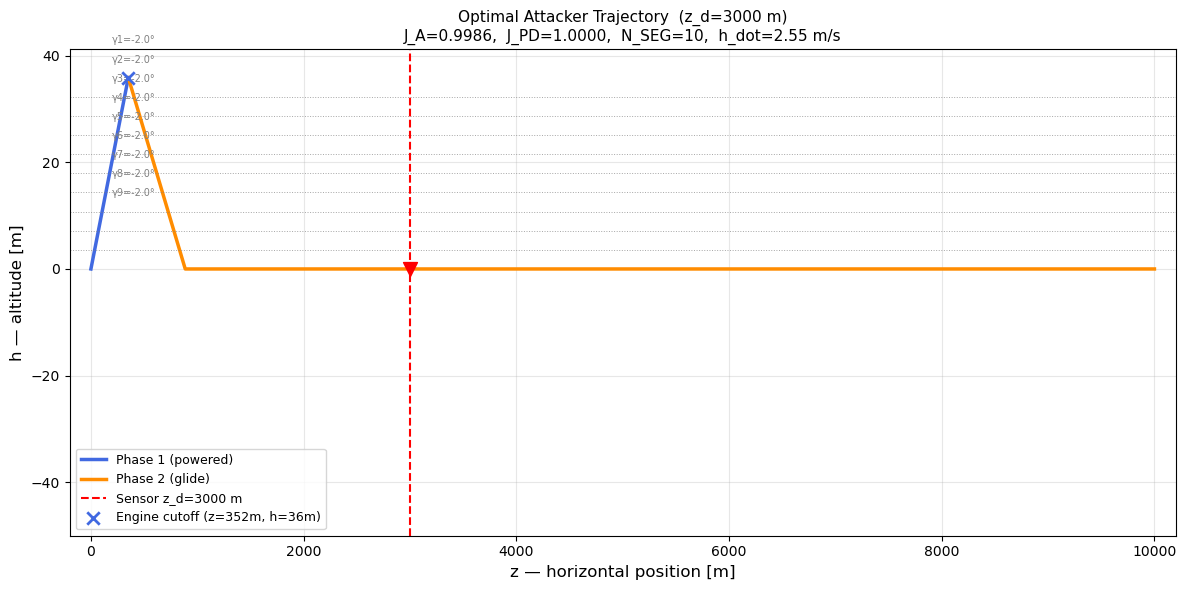

Plot 1 saved.


In [8]:
traj    = result['traj']
jpd_run = result['jpd_run']
rates   = result['rates']
gammas  = result['gammas']

phase1_m = traj['phase'] == 1
phase2_m = traj['phase'] == 2
cutoff_t = traj['t'][np.argmax(phase2_m)]

# Segment altitude boundaries for glide phase
h_sw     = traj['h_sw']
seg_bounds = np.linspace(h_sw, 0.0, N_SEG + 1)


# ── Plot 1: Trajectory shape ─────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(traj['z'][phase1_m], traj['h'][phase1_m],
         color='royalblue', linewidth=2.5, label='Phase 1 (powered)')
ax1.plot(traj['z'][phase2_m], traj['h'][phase2_m],
         color='darkorange', linewidth=2.5, label='Phase 2 (glide)')

# Mark segment boundaries as horizontal lines in the glide phase
for i, h_b in enumerate(seg_bounds[1:-1]):   # skip top and bottom
    # Find z at this altitude in the glide phase
    idx = np.argmin(np.abs(traj['h'][phase2_m] - h_b))
    z_at_h = traj['z'][phase2_m][idx]
    ax1.axhline(h_b, color='gray', linewidth=0.7, linestyle=':', alpha=0.7)
    ax1.text(Z_START + 200, h_b + 10,
             f'γ{i+1}={np.degrees(gammas[i]):.1f}°',
             fontsize=7, color='gray')

# Sensor location
ax1.axvline(Z_D, color='red', linewidth=1.5, linestyle='--',
            label=f'Sensor z_d={Z_D:.0f} m')
ax1.scatter([Z_D], [0], color='red', zorder=6, s=100, marker='v')

# Engine cutoff marker
z_sw = traj['z_sw']
ax1.scatter([z_sw], [h_sw], color='royalblue', zorder=6, s=80,
            marker='x', linewidths=2, label=f'Engine cutoff (z={z_sw:.0f}m, h={h_sw:.0f}m)')

ax1.set_xlabel('z — horizontal position [m]', fontsize=12)
ax1.set_ylabel('h — altitude [m]', fontsize=12)
ax1.set_title(
    f'Optimal Attacker Trajectory  (z_d={Z_D:.0f} m)\n'
    f'J_A={result["J_A"]:.4f},  J_PD={result["J_PD"]:.4f},  '
    f'N_SEG={N_SEG},  h_dot={result["h_dot"]:.2f} m/s',
    fontsize=11
)
ax1.set_xlim([Z_START - 200, Z_GOAL + 200])
ax1.set_ylim([-50, max(traj['h']) * 1.15])
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot1_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 saved.')

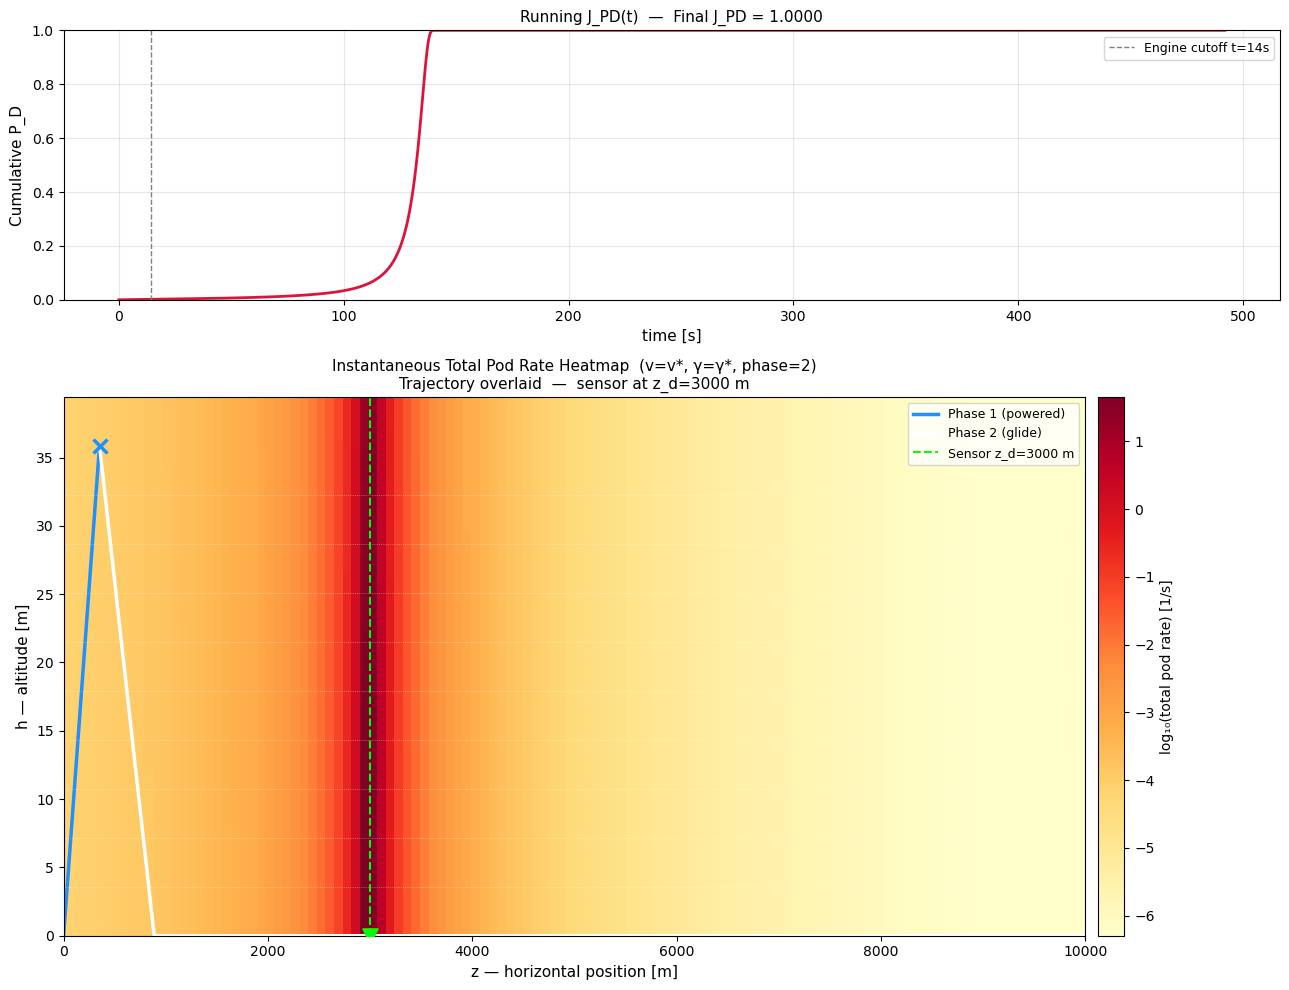

Plot 2 saved.


In [9]:
# ── Plot 2: Cumulative P_D + Heatmap ─────────────────────────────────────────

# Build heatmap of instantaneous total pod rate over (z, h) grid
# Use gamma=gamma* and glide phase (phase=2) for the background map
n_z, n_h   = 120, 80
z_grid     = np.linspace(Z_START, Z_GOAL,    n_z)
h_grid     = np.linspace(0,       max(traj['h']) * 1.1, n_h)
ZZ, HH     = np.meshgrid(z_grid, h_grid)

v_ref_map  = glide_speed(GAMMA_STAR)   # reference airspeed for heatmap
rate_map   = np.zeros((n_h, n_z))

for i in range(n_h):
    for j in range(n_z):
        rate_map[i, j] = lambda_total(
            ZZ[i, j], HH[i, j], v_ref_map, GAMMA_STAR, phase=2
        )

# Log scale for heatmap so low rates are visible
rate_map_log = np.log10(np.maximum(rate_map, 1e-12))

fig2, axes = plt.subplots(2, 1, figsize=(13, 10),
                           gridspec_kw={'height_ratios': [1, 2]})

# ── Top panel: Cumulative P_D over time ──────────────────────────────────────
ax_top = axes[0]
ax_top.plot(traj['t'], jpd_run, color='crimson', linewidth=2)
ax_top.axvline(cutoff_t, color='gray', linestyle='--',
               linewidth=1, label=f'Engine cutoff t={cutoff_t:.0f}s')
ax_top.set_xlabel('time [s]', fontsize=11)
ax_top.set_ylabel('Cumulative P_D', fontsize=11)
ax_top.set_title(
    f'Running J_PD(t)  —  Final J_PD = {result["J_PD"]:.4f}',
    fontsize=11
)
ax_top.set_ylim([0, 1])
ax_top.legend(fontsize=9)
ax_top.grid(True, alpha=0.3)

# ── Bottom panel: Heatmap + trajectory overlay ───────────────────────────────
ax_bot = axes[1]

im = ax_bot.pcolormesh(ZZ, HH, rate_map_log,
                        cmap='YlOrRd', shading='auto',
                        vmin=np.percentile(rate_map_log, 10),
                        vmax=np.percentile(rate_map_log, 99))
cbar = fig2.colorbar(im, ax=ax_bot, pad=0.01)
cbar.set_label('log₁₀(total pod rate) [1/s]', fontsize=10)

# Overlay trajectory
ax_bot.plot(traj['z'][phase1_m], traj['h'][phase1_m],
            color='dodgerblue', linewidth=2.5, label='Phase 1 (powered)')
ax_bot.plot(traj['z'][phase2_m], traj['h'][phase2_m],
            color='white', linewidth=2.5, label='Phase 2 (glide)')

# Segment boundaries
for h_b in seg_bounds[1:-1]:
    ax_bot.axhline(h_b, color='white', linewidth=0.5,
                   linestyle=':', alpha=0.6)

# Sensor
ax_bot.axvline(Z_D, color='lime', linewidth=1.5, linestyle='--',
               label=f'Sensor z_d={Z_D:.0f} m')
ax_bot.scatter([Z_D], [0], color='lime', zorder=6, s=120, marker='v')

# Engine cutoff
ax_bot.scatter([z_sw], [h_sw], color='dodgerblue', zorder=6,
               s=100, marker='x', linewidths=2.5)

ax_bot.set_xlabel('z — horizontal position [m]', fontsize=11)
ax_bot.set_ylabel('h — altitude [m]', fontsize=11)
ax_bot.set_title(
    f'Instantaneous Total Pod Rate Heatmap  '
    f'(v=v*, γ=γ*, phase=2)\n'
    f'Trajectory overlaid  —  sensor at z_d={Z_D:.0f} m',
    fontsize=11
)
ax_bot.set_xlim([Z_START, Z_GOAL])
ax_bot.set_ylim([0, max(traj['h']) * 1.1])
ax_bot.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('plot2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 saved.')

---
## Section 8 — Summary

In [10]:
print('=' * 55)
print('RESULTS SUMMARY')
print('=' * 55)
print(f'\nScenario:')
print(f'  Corridor:  z=[{Z_START:.0f}, {Z_GOAL:.0f}] m')
print(f'  Sensor:    z_d={Z_D:.0f} m')
print(f'  Segments:  N={N_SEG}')
print(f'\nOptimal attacker trajectory:')
print(f'  h_dot  = {result["h_dot"]:.3f} m/s')
print(f'  h_sw   = {result["h_sw"]:.1f} m')
print(f'  z_sw   = {result["traj"]["z_sw"]:.1f} m')
print(f'  gammas = {np.degrees(result["gammas"]).round(2)} deg')
print(f'\nCosts:')
print(f'  J_PD   = {result["J_PD"]:.4f}')
print(f'  T_norm = {result["T_norm"]:.4f}')
print(f'  J_A    = {result["J_A"]:.4f}')
print(f'\nGamma variation (key result):')
print(f'  min gamma = {np.degrees(result["gammas"].min()):.2f} deg')
print(f'  max gamma = {np.degrees(result["gammas"].max()):.2f} deg')
print(f'  std dev   = {np.degrees(result["gammas"].std()):.4f} deg')
if result['gammas'].std() < np.radians(0.5):
    print(f'  → All gammas nearly equal: sensors may need recalibration')
else:
    print(f'  → Gammas vary across segments: three-way contradiction active ✓')
print('=' * 55)

RESULTS SUMMARY

Scenario:
  Corridor:  z=[0, 10000] m
  Sensor:    z_d=3000 m
  Segments:  N=10

Optimal attacker trajectory:
  h_dot  = 2.550 m/s
  h_sw   = 35.9 m
  z_sw   = 351.6 m
  gammas = [-2. -2. -2. -2. -2. -2. -2. -2. -2. -2.] deg

Costs:
  J_PD   = 1.0000
  T_norm = 0.9955
  J_A    = 0.9986

Gamma variation (key result):
  min gamma = -2.00 deg
  max gamma = -2.00 deg
  std dev   = 0.0000 deg
  → All gammas nearly equal: sensors may need recalibration


In [11]:
# # All shallow
# gammas_shallow = np.full(N_SEG, GAMMA_MAX)
# traj_shallow   = simulate_trajectory(result['h_dot'], result['h_sw'], gammas_shallow)
# J_A_s, J_PD_s, _, _, _ = compute_ja(traj_shallow, z_d=Z_D)

# # All steep
# gammas_steep = np.full(N_SEG, GAMMA_MIN)
# traj_steep   = simulate_trajectory(result['h_dot'], result['h_sw'], gammas_steep)
# J_A_st, J_PD_st, _, _, _ = compute_ja(traj_steep, z_d=Z_D)

# # Optimal from Nelder-Mead
# J_A_opt = result['J_A']

# print(f'Shallow: J_A={J_A_s:.4f}, J_PD={J_PD_s:.4f}')
# print(f'Steep:   J_A={J_A_st:.4f}, J_PD={J_PD_st:.4f}')
# print(f'Optimal: J_A={J_A_opt:.4f}')
# print(f'J_A range: {abs(J_A_s - J_A_st):.4f}')